# Model Comparison

All thirteen models side by side, from `reports/results.csv` (every metric is mean ± std over seeds 42, 43, 44). Run
the model notebooks (or `python run_all.py`) first. The figure is saved to `visualizations/model_comparison.png`.

## 1. Setup

In [1]:
import sys, pathlib, warnings
ROOT = next((p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents) if (p / 'src' / 'config.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the project folder (the one that contains src/).')
sys.path.insert(0, str(ROOT))   # project root -> `import src`, whatever the working folder
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
from src import config
from src.evaluation import read_results
from src.plotting import plot_model_comparison

## 2. Results table

In [2]:
table, num = read_results()
table.set_index('Model')

,Train RMSE,CV RMSE,Val RMSE,Test RMSE,Test R²,Test MAE,Test Median % Error
Model,,,,,,,
Baseline (Mean),58725.40 ± 3475.23,57777.26 ± 3623.48,64671.30 ± 13191.56,53731.47 ± 2975.65,0.00 ± 0.00,29309.15 ± 166.32,112.33 ± 2.41
Baseline (Median),61416.52 ± 3435.08,60573.36 ± 3662.61,67340.01 ± 13089.97,56582.69 ± 2929.16,-0.11 ± 0.01,23617.00 ± 329.82,55.13 ± 0.73
Baseline (Locality × Size),34319.90 ± 1198.12,36456.09 ± 2370.63,41289.66 ± 10163.69,31953.02 ± 1545.72,0.65 ± 0.01,12737.74 ± 664.05,26.86 ± 1.45
Linear Regression,32939.54 ± 1496.73,32602.31 ± 1405.71,33182.74 ± 8018.50,25680.00 ± 1099.13,0.77 ± 0.01,10350.93 ± 208.57,21.78 ± 1.39
Ridge Regression,33246.83 ± 1892.57,32296.85 ± 1748.68,34153.29 ± 9433.52,25145.91 ± 675.22,0.78 ± 0.02,10357.28 ± 114.91,22.08 ± 0.86
Lasso Regression,33174.65 ± 1841.19,32172.94 ± 1663.45,33887.03 ± 9146.57,25085.16 ± 657.92,0.78 ± 0.02,10362.23 ± 115.25,22.47 ± 1.06
Elastic Net,33192.92 ± 1849.94,32182.31 ± 1687.32,33902.41 ± 9165.95,25074.55 ± 621.69,0.78 ± 0.02,10356.85 ± 126.94,22.47 ± 1.04
Decision Tree,27402.37 ± 1017.54,31136.02 ± 890.77,32349.47 ± 10485.54,25058.91 ± 1172.89,0.78 ± 0.01,10505.89 ± 643.13,24.16 ± 1.12
Random Forest,13546.84 ± 997.20,30666.46 ± 2073.53,31441.57 ± 7655.81,23563.17 ± 1591.13,0.81 ± 0.02,9930.91 ± 413.62,22.54 ± 0.54


## 3. Test error by model

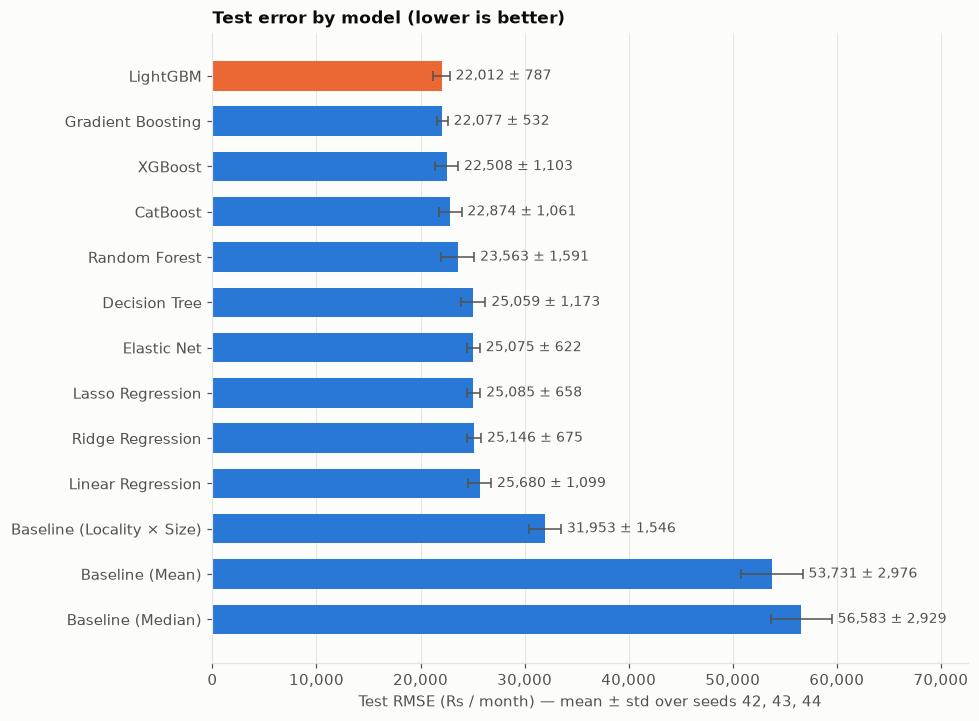

In [3]:
best = num.sort_values('Test RMSE mean')['Model'].iloc[0]
fig = plot_model_comparison(num, highlight=best, save_path=config.VIZ_DIR / 'model_comparison.png')

## 4. Overfitting check — how much worse is unseen data than training data?

In [4]:
gap = num.set_index('Model')[['Train RMSE mean', 'CV RMSE mean', 'Test RMSE mean']]
gap.columns = ['Train RMSE', 'CV RMSE', 'Test RMSE']
gap['CV − Train'] = gap['CV RMSE'] - gap['Train RMSE']
gap.sort_values('Test RMSE')

,Train RMSE,CV RMSE,Test RMSE,CV − Train
Model,,,,
LightGBM,"23,721.43","28,806.22","22,012.13","5,084.79"
Gradient Boosting,"27,519.54","28,808.51","22,076.71","1,288.97"
XGBoost,"21,480.97","29,919.90","22,507.83","8,438.93"
CatBoost,"14,400.28","30,517.02","22,874.45","16,116.74"
Random Forest,"13,546.84","30,666.46","23,563.17","17,119.62"
Decision Tree,"27,402.37","31,136.02","25,058.91","3,733.65"
Elastic Net,"33,192.92","32,182.31","25,074.55","-1,010.61"
Lasso Regression,"33,174.65","32,172.94","25,085.16","-1,001.71"
Ridge Regression,"33,246.83","32,296.85","25,145.91",-949.98


**Reading it.** Lower is better. One model is clearly better than another only when the gap between their means is
large compared with their ± spreads — the top boosting models are close to a tie. A large positive *CV − Train* means
the model fits its training rows much better than rows it has not seen (overfitting); the constant baselines have none
because they predict a constant.

## 5. Median % error — a second view
RMSE in rupees is dominated by a few very expensive homes. The median % error is the typical miss relative to the
home's own rent: half the predictions are closer than this, half further. The **locality × size** baseline is the
rule of thumb (local rent per sq ft × size); the gap to it is what the machine-learning models really add.

In [5]:
view = num.set_index('Model')[['Test RMSE mean', 'Test Median % Error mean', 'Test Median % Error std']]
view.columns = ['Test RMSE', 'Median % error', '± (seeds)']
rule = view.loc['Baseline (Locality × Size)']
view['RMSE vs rule of thumb'] = (view['Test RMSE'] / rule['Test RMSE'] - 1).map('{:+.0%}'.format)
view['Median % error vs rule of thumb'] = (view['Median % error'] - rule['Median % error']).map('{:+.1f} pts'.format)
view.sort_values('Test RMSE')

,Test RMSE,Median % error,± (seeds),RMSE vs rule of thumb,Median % error vs rule of thumb
Model,,,,,
LightGBM,"22,012.13",21.51,0.81,-31%,-5.3 pts
Gradient Boosting,"22,076.71",20.95,1.00,-31%,-5.9 pts
XGBoost,"22,507.83",21.14,0.65,-30%,-5.7 pts
CatBoost,"22,874.45",20.78,0.45,-28%,-6.1 pts
Random Forest,"23,563.17",22.54,0.54,-26%,-4.3 pts
Decision Tree,"25,058.91",24.16,1.12,-22%,-2.7 pts
Elastic Net,"25,074.55",22.47,1.04,-22%,-4.4 pts
Lasso Regression,"25,085.16",22.47,1.06,-21%,-4.4 pts
Ridge Regression,"25,145.91",22.08,0.86,-21%,-4.8 pts
